In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

pa_gs = pd.read_csv('data/pa_data.csv')

In [4]:
X = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']
y = ['growing_season_length']

In [5]:
def remove_nulls(data_subset, X, y):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        y_cleaned = y_cleaned.squeeze()
        return X_cleaned, y_cleaned

X_gs, y = remove_nulls(pa_gs, X, y)

In [6]:
def principal_component_analysis(X, y):
    #creates and graphs principal component analysis for inputted X and y
    #required libraries: from sklearn.preprocessing import StandardScalar, from sklearn.decomposition import PCA,
    #from sklearn.linear_model import LinearRegression, matplotlib.pyplot as plt, numpy as np, seaborn as sns

    #gets list of columns in input X for future conversion of X_train back into dataframe
    columns_X = list(X.columns)

    # splits data into X_train, X_test, y_train, and y_test and makes X_train a dataframe
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_train = pd.DataFrame(X_train, columns = columns_X)

    # First PCA
    pca1 = PCA()
    X_pca1 = pca1.fit_transform(X_train)
    plt.bar(range(1,len(pca1.explained_variance_)+1),pca1.explained_variance_)
    plt.ylabel('Explained Variance')
    plt.xlabel('Components')
    plt.plot(range(1,len(pca1.explained_variance_)+1), np.cumsum(pca1.explained_variance_), 
         c='red', label = 'Cumulative Explained Variance')
    plt.legend(loc='upper left')
    plt.show()

    # Second PCA
    pca2b = PCA(n_components=2)
    X_pca2b = pca2b.fit_transform(X_train)
    colormap = plt.get_cmap('coolwarm')
    plt.figure()
    scatter = plt.scatter(X_pca2b[:, 0], X_pca2b[:, 1], c=y_train, cmap= colormap)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.colorbar(scatter, label = 'Growing Season Length')
    plt.show()

    # Third PCA
    pca3 = PCA(n_components=5)
    X_pca3 = pca3.fit_transform(X_train)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=y_train, cmap=colormap)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    plt.show()

    loadings = pca3.components_.T * np.sqrt(pca3.explained_variance_)
    plt.figure(figsize=(10, 8))
    sns.heatmap(loadings, annot=True, cmap='coolwarm', xticklabels=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], yticklabels=X.columns)
    plt.title('Feature Importance in Principal Components')
    plt.show()

    return loadings

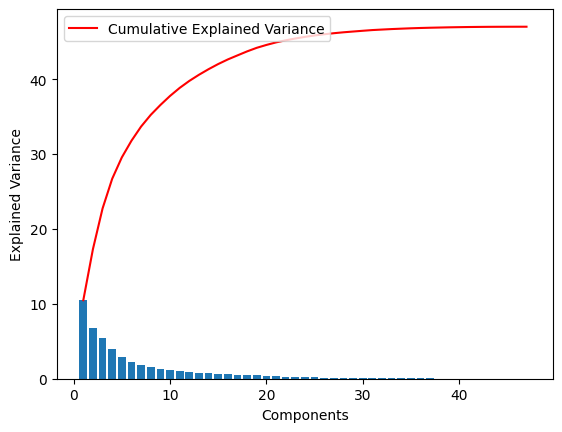

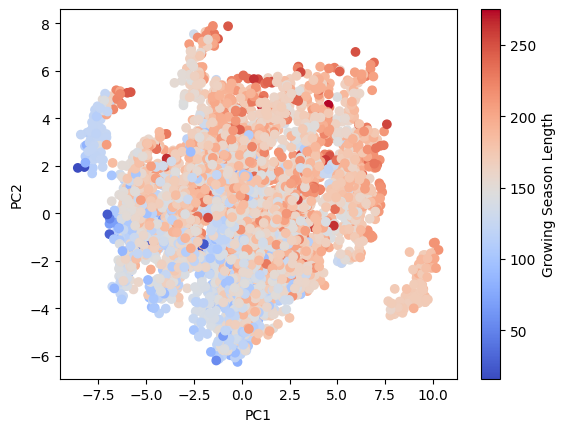

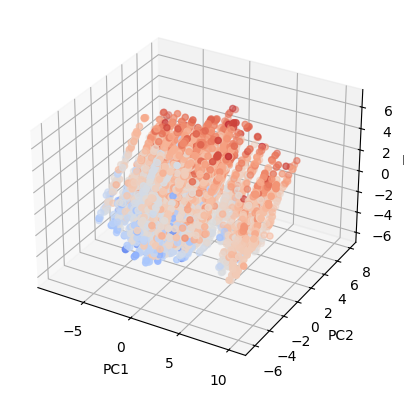

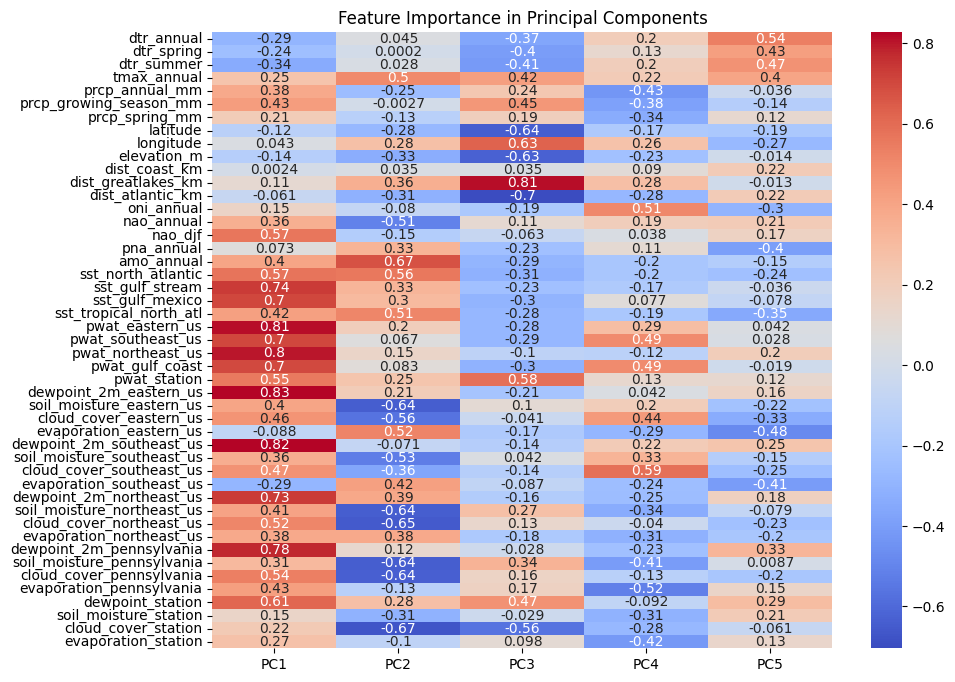

In [12]:
loadings = principal_component_analysis(X_gs, y)

In [8]:
y_lsf = ['last_spring_frost_doy']
x_lsf, y_lsf = remove_nulls(pa_gs, X, y_lsf)
y_fff = ['first_fall_frost_doy']
x_fff, y_fff = remove_nulls(pa_gs, X, y_fff)

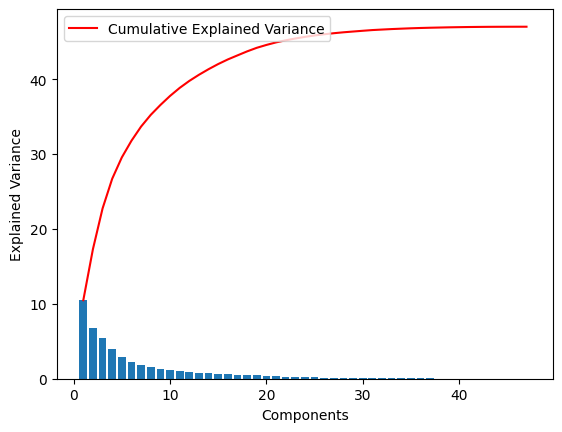

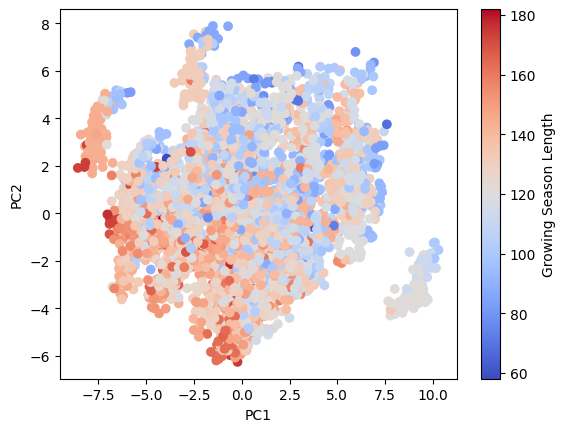

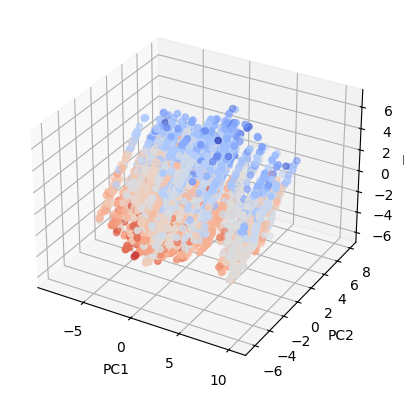

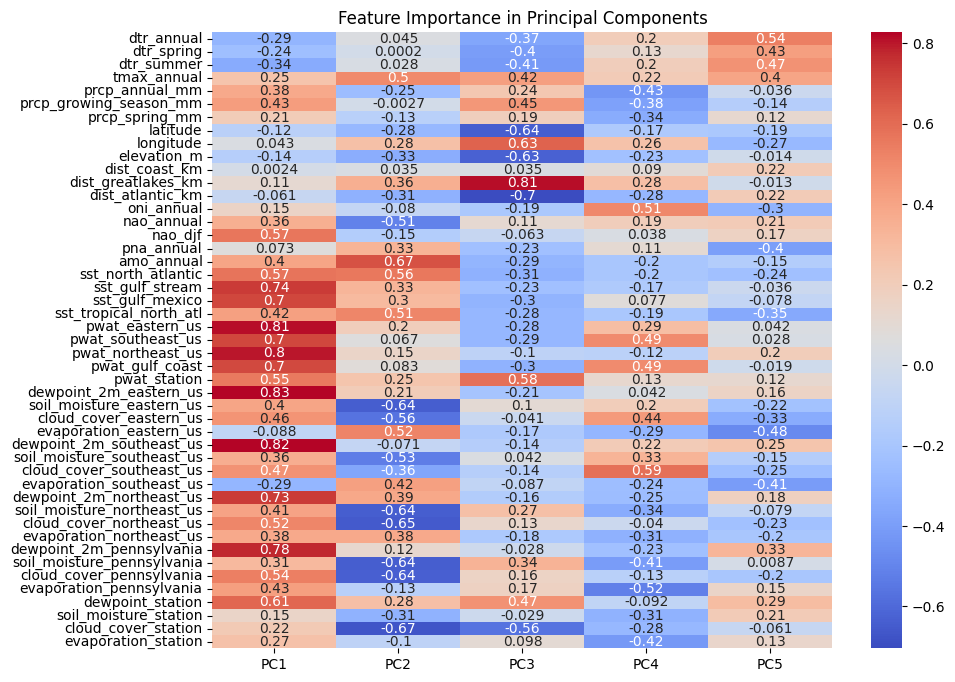

array([[-2.92405863e-01,  4.53954381e-02, -3.65246907e-01,
         2.04654045e-01,  5.35378014e-01],
       [-2.40355882e-01,  1.96642142e-04, -4.01878440e-01,
         1.26842433e-01,  4.26026190e-01],
       [-3.41050632e-01,  2.76234016e-02, -4.10895792e-01,
         1.96396180e-01,  4.72773443e-01],
       [ 2.53932033e-01,  4.99174047e-01,  4.22280162e-01,
         2.15243522e-01,  4.01089151e-01],
       [ 3.82475440e-01, -2.53084772e-01,  2.35550811e-01,
        -4.28903448e-01, -3.57461575e-02],
       [ 4.32158062e-01, -2.74703691e-03,  4.53130061e-01,
        -3.83221603e-01, -1.44489792e-01],
       [ 2.09184958e-01, -1.28384079e-01,  1.92875068e-01,
        -3.37766817e-01,  1.19590981e-01],
       [-1.19580318e-01, -2.78867154e-01, -6.43189778e-01,
        -1.74798425e-01, -1.88296324e-01],
       [ 4.34455196e-02,  2.75329189e-01,  6.26759450e-01,
         2.59543228e-01, -2.70043953e-01],
       [-1.36452120e-01, -3.27319138e-01, -6.31978705e-01,
        -2.26765968e-01

In [9]:
principal_component_analysis(x_lsf, y_lsf)

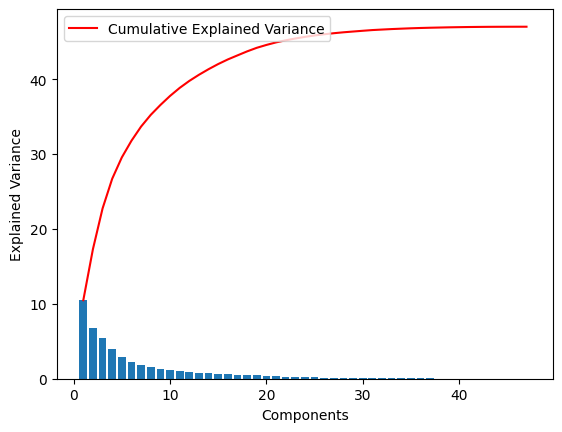

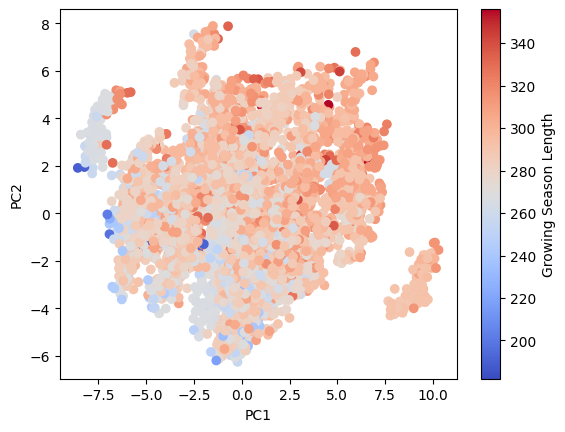

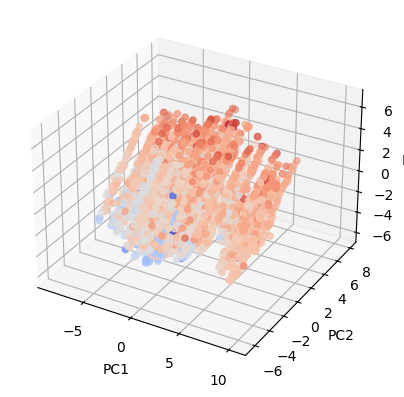

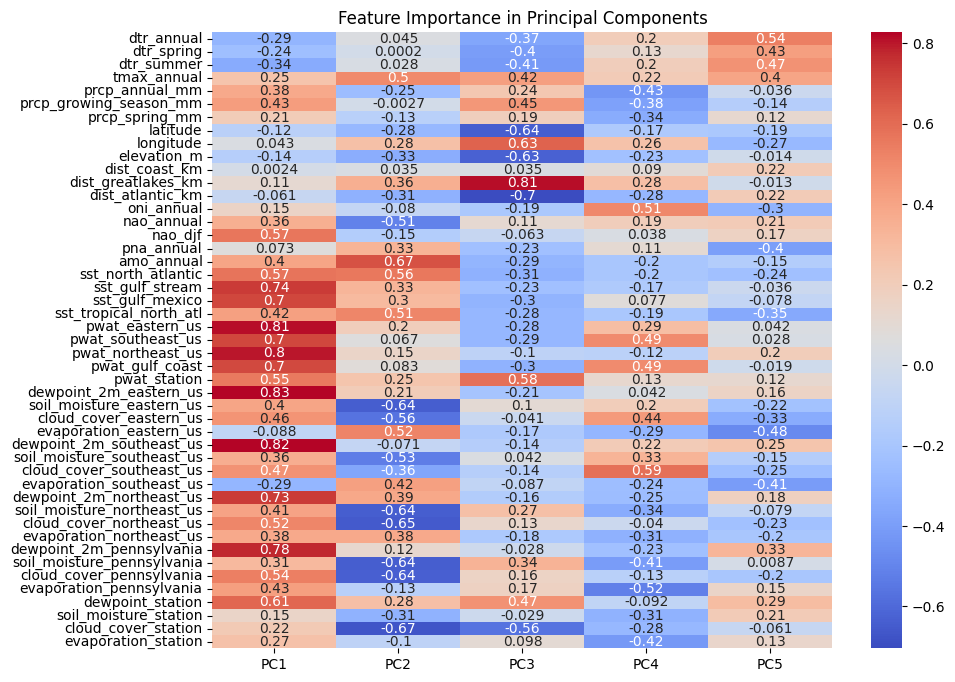

array([[-2.92405863e-01,  4.53954381e-02, -3.65246907e-01,
         2.04654045e-01,  5.35378014e-01],
       [-2.40355882e-01,  1.96642142e-04, -4.01878440e-01,
         1.26842433e-01,  4.26026190e-01],
       [-3.41050632e-01,  2.76234016e-02, -4.10895792e-01,
         1.96396180e-01,  4.72773443e-01],
       [ 2.53932033e-01,  4.99174047e-01,  4.22280162e-01,
         2.15243522e-01,  4.01089151e-01],
       [ 3.82475440e-01, -2.53084772e-01,  2.35550811e-01,
        -4.28903448e-01, -3.57461575e-02],
       [ 4.32158062e-01, -2.74703691e-03,  4.53130061e-01,
        -3.83221603e-01, -1.44489792e-01],
       [ 2.09184958e-01, -1.28384079e-01,  1.92875068e-01,
        -3.37766817e-01,  1.19590981e-01],
       [-1.19580318e-01, -2.78867154e-01, -6.43189778e-01,
        -1.74798425e-01, -1.88296324e-01],
       [ 4.34455196e-02,  2.75329189e-01,  6.26759450e-01,
         2.59543228e-01, -2.70043953e-01],
       [-1.36452120e-01, -3.27319138e-01, -6.31978705e-01,
        -2.26765968e-01

In [10]:
principal_component_analysis(x_fff, y_fff)

# Rotating PCA #

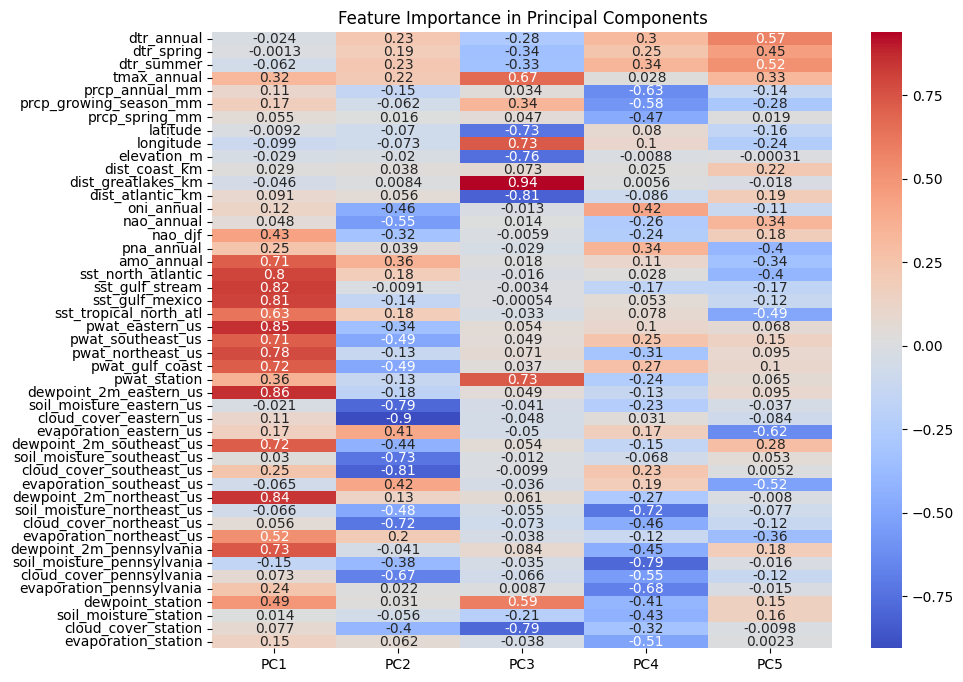

In [17]:
from factor_analyzer import Rotator
rotator = Rotator(method='varimax')
loadings_rotated = pd.DataFrame(rotator.fit_transform(loadings))

plt.figure(figsize=(10, 8))
sns.heatmap(loadings_rotated, annot=True, cmap='coolwarm', xticklabels=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'], yticklabels=X_gs.columns)
plt.title('Feature Importance in Principal Components')
plt.show()